# QF 627 Programming and Computational Finance
## Problem Set `7` | `Questions`

> Hi, Team 👋

> The exercise requires you to solve two overarching sets of questions. As with our previous exercise problem sets, while answering the questions you will be able to incorporate what you learned in class and consolidate your understanding.

> Enjoy 🤞

### For standardization of your answers…

> Please execute the lines of code below before you start work on your answers.

In [1]:
# %pip install -r "../requirements.txt"

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [3]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

## 👇 <font color = "purple"> Bigger Question 1. 

> Here's something that's familiar to you, with a few minor tweaks.

### Please create a predictive model for the weekly return of AMZN stock. You will use supervised learning for your predictive modelling.

> As you learned in class, to do this it is essential to know what factors are related to Amazon’s stock price, and to incorporate as much information as you can into the model.

> Among the three major factors (correlated assets, technical indicators, and fundamental analysis), you will use correlated assets and technical indicators as features here.

    Step 1. Use 75% of your data for the training of your algorithm, and 25% for the testing set.

    Step 2. For your feature engineering...
    
> Our operational definition of `outcome` (`Y`) is the weekly return of Amazon (AMZN). The number of trading days in a week is assumed to be five, and we compute the return using five trading days. 
<br>
    
* <font color = "green"> NOTE: The lagged five-day variables embed the time series component by using a time-delay approach, where the lagged variable is included as one of the predictor variables. This step translates the time series data into a supervised regression-based model framework.
<br>    
    
> For `input features` (`predictors`; `Xs`), we use (The variables used as predictors are as follows) ...

> `Correlated assets`

* lagged five-day returns of stocks (AAPL, MSFT, F);
* currency exchange rates (USD/JPY and GBP/USD);
* indices (S&P 500, Dow Jones, and VIX);
* lagged five-day, 15-day, 30-day, and 60-day returns of AMZN.

> `Technical indicators`

* 21-day, 63-day, and 252-day moving averages;
* 10-day, 30-day, and 200-day exponential moving averages.

    
    Step 3. For your algorithm of choices, please assess the model performance of the following algorithms: 

* Linear Regression
* Elastic Net
* LASSO
* Support Vector Machine
* K-Nearest Neighbor
* ARIMA
* Decision Tree
* Extra Trees 
* Random Forest
* Gradient Boosting Tree
* Adaptive Boosting
    
    
    Step 4. For this exercise, hyperparameter tuning won’t be requested. 
    
    Step 5. But make sure to compare the model performance of the above algorithms.

> The metric for assessing model performance will be mean squared error (`MSE`).
<br>

> Show which of the algorithms perform relatively better by a comparison visualization of performance, for both the training and testing sets learned in class. 

    Step 6. Using the model of your choice, please visualize the actual vs. predicted (estimated) data.

# TODO list
1. download tickers data
2. compute X
3. join X and Y to get the same index
4. train test split
5. regress against models
6. get positions and signals for each strat
7. compute returns and cum rets
8. compute mse for all
9. plot for one of the models

### Below are the lines of code that lead to an answer:

In [4]:
target = 'AMZN'
stock_tickers = [
    "AMZN", "AAPL", "MSFT", "F"    # Stocks
]
index_tickers = [
    "^GSPC", "^DJI", "^VIX"        # Indices
]
ccy_tickers = [
    "JPY=X", "GBPUSD=X"           # FX rates
]
tickers = stock_tickers + index_tickers + ccy_tickers

ticker_data =\
(
    yf.download(
        tickers,
        start = dt.datetime(2013, 1, 7),
        auto_adjust=False
    )
)['Adj Close']
# remove nulls
ticker_data = ticker_data.ffill()

[*********************100%***********************]  9 of 9 completed


In [5]:
sub_df_list = []

In [6]:
# 5 day lags for all stocks
df_rets = ticker_data[[ticker for ticker in stock_tickers if ticker != target]].copy()
lag = 5
df_rets = df_rets.pct_change(lag).shift(1).rename(columns={f'{ticker}':f'{ticker}_ret_{lag}' for ticker in stock_tickers})

sub_df_list.append(df_rets)

In [7]:
# get ccy 
sub_df_list.append(ticker_data[ccy_tickers].copy())
# get indices
sub_df_list.append(ticker_data[index_tickers].copy())

In [8]:

# lagged five-day, 15-day, 30-day, and 60-day returns of AMZN.
lag_list = [5, 15, 30, 60]
df_rets = ticker_data[[target]].copy()

for lag in lag_list:
    df_rets[f'{target}_ret_{lag}'] = df_rets[target].pct_change(lag).shift(1)
    
df_rets = df_rets.drop(columns=target)

sub_df_list.append(df_rets)

In [9]:
# get sma
def get_sma(df, sma_list):
    """
    Take DF and given list of SMA to enrich df when stock price is in first column
    """
    for window in sma_list:
        df[f"sma_{window}"] =\
        (
            df[df.columns[0]]
            .rolling(window = window,
                     min_periods = int(window * .8))
            .mean()
        )

    return df

sma_list = [21, 63, 252]
df_sma = get_sma(ticker_data[[target]].copy(), sma_list).drop(columns=target)

sub_df_list.append(df_sma)



In [10]:
# get EMA
def get_ema(df, ema_list):
    """
    Take DF and given list of EMA to enrich df when stock price is in first column
    """
    for window in ema_list:
        df[f"ema_{window}"] =\
        (
            df[df.columns[0]]
            .ewm(span = window)
            .mean()
        )

    return df

ema_list = [10, 30, 200]
df_ema = get_ema(ticker_data[[target]].copy(), ema_list).drop(columns=target)

sub_df_list.append(df_ema)

In [21]:
# y parameter
fwd = 5
df_fwd_rets = ticker_data[[target]].copy()

df_fwd_rets[f"{target}_fwd_rets"] = df_fwd_rets.pct_change(fwd).shift(-fwd).shift(-1)
    
df_fwd_rets = df_fwd_rets.drop(columns=target)
sub_df_list.append(df_fwd_rets)

In [23]:
# combine df
df =\
(
    pd.concat(sub_df_list,axis=1)
)
# fill forward for NaN
df =\
(
    df.ffill().dropna()
)

In [24]:
X = df.drop(columns=[f'{target}_fwd_rets'])
y = df[[f'{target}_fwd_rets']]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=False)

[ a.shape for a in [X_train, X_test, y_train, y_test ]]

[(2360, 18), (787, 18), (2360, 1), (787, 1)]

In [26]:
# prepare evaluation suite
from sklearn.metrics import mean_squared_error

mse_results = {}

def get_mse_train_test(model, X_train, y_train, X_test, y_test, name=None):
    """
    Compute MSE on train and test and store results in mse_results.
    If name is not provided, use model class name.
    """
    global mse_results
    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_train_pred)

    y_test_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, y_test_pred)

    model_name = name or model.__class__.__name__
    if model_name == "GridSearchCV":
        model_name = str(type(model.best_estimator_)).split(".")[-1].replace("'>", "")
    mse_results[str(model_name)] = {'mse_train': mse_train, 'mse_test': mse_test}

    print(f"Mean Squared Error (MSE) for {model_name}")
    print(f"MSE train: {mse_train:.6f}")
    print(f"MSE test: {mse_test:.6f}")

    return mse_train, mse_test

In [27]:
## Linear regression
import statsmodels.api as sm

# Ensure X_train is a DataFrame with column names
X_train_df = sm.add_constant(X_train)
X_test_df = sm.add_constant(X_test) # Add intercept

lr = sm.OLS(y_train, X_train_df).fit()
display(lr.summary())
get_mse_train_test(lr, 
                   X_train_df, 
                   y_train, 
                   X_test_df,
                   y_test, 
                   name="LR")

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          AMZN_fwd_rets   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     6.032
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           1.41e-14
Time:                        10:56:17   Log-Likelihood:                 4034.5
No. Observations:                2360   AIC:                            -8031.
Df Residuals:                    2341   BIC:                            -7921.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0756      0.028      2.724      0.006       0.021       0.130
AAPL_ret_5      0.1217      0.032      3.794      0.000       0.059       0.185
MSFT_ret_5     -0.0836      0.039     -2.128      0.033      -0.161      -0.007
F_ret_5         0.0131      0.021      0.626      0.531      -0.028       0.054
JPY=X          -0.0007      0.000     -4.398      0.000      -0.001      -0.000
GBPUSD=X       -0.0147      0.010     -1.526      0.127      -0.034       0.004
^GSPC       -9.981e-06   9.95e-06     -1.003      0.316   -2.95e-05    9.53e-06
^DJI         2.301e-06   1.09e-06      2.106      0.035    1.58e-07    4.44e-06
^VIX            0.0010      0.000      4.828      0.000       0.001       0.001
AMZN_ret_5     -0.0019      0.031     -0.061      0.951      -0.063       0.059
AMZN_ret_15    -0.0185      0.026     -0.712      0.476      -0.069       0.032
AMZN_ret_30     0.0450      0.020      2.219      0.027       0.005       0.085
AMZN_ret_60    -0.0053      0.012     -0.427      0.670      -0.030       0.019
sma_21         -0.0054      0.002     -2.969      0.003      -0.009      -0.002
sma_63         -0.0030      0.001     -2.967      0.003      -0.005      -0.001
sma_252        -0.0005      0.001     -0.772      0.440      -0.002       0.001
ema_10         -0.0037      0.001     -3.776      0.000      -0.006      -0.002
ema_30          0.0115      0.003      3.432      0.001       0.005       0.018
ema_200         0.0009      0.001      0.748      0.455      -0.001       0.003
==============================================================================
Omnibus:                      133.972   Durbin-Watson:                   0.430
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              501.762
Skew:                          -0.127   Prob(JB):                    1.11e-109
Kurtosis:                       5.245   Cond. No.                     1.22e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.22e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Mean Squared Error (MSE) for LR
MSE train: 0.001917
MSE test: 0.003463


(0.001917044034012106, 0.003462854367819288)

In [28]:
# ----------------------------------------------------------------------------
# 1. ELASTIC NET
# ----------------------------------------------------------------------------
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=1000, random_state=42)
elastic_net.fit(X_train, y_train)
y_pred_en = elastic_net.predict(X_test)
print(f"Elastic Net - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_en)):.4f}")
# # Hyperparameter tuning
# param_grid_en = {
#     'alpha': [0.01, 0.1, 10.0],
#     'l1_ratio': [0.1, 0.9]
# }
# grid_en = GridSearchCV(ElasticNet(max_iter=1000), param_grid_en, cv=5, scoring='neg_root_mean_squared_error')
# grid_en.fit(X_train, y_train)
# print(f"Best Elastic Net params: {grid_en.best_params_}")
# metrics
mse_train, mse_test = get_mse_train_test(elastic_net, X_train, y_train, X_test, y_test)

Elastic Net - RMSE: 0.0571
Mean Squared Error (MSE) for ElasticNet
MSE train: 0.001945
MSE test: 0.003256


/Users/ju/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.742e+00, tolerance: 4.734e-04
  model = cd_fast.enet_coordinate_descent(


In [29]:
# ----------------------------------------------------------------------------
# 2. LASSO
# ----------------------------------------------------------------------------
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, max_iter=1000, random_state=42)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print(f"LASSO - MSE: {mean_squared_error(y_test, y_pred_lasso):.4f}")

# Feature selection with LASSO
n_nonzero = np.sum(lasso.coef_ != 0)
# print(f"LASSO selected {n_nonzero} features out of {X_reg.shape[1]}")

mse_train, mse_test = get_mse_train_test(lasso, 
                                         X_train, 
                                         y_train, 
                                         X_test, 
                                         y_test)

LASSO - MSE: 0.0026
Mean Squared Error (MSE) for Lasso
MSE train: 0.001957
MSE test: 0.002639


In [30]:
# ----------------------------------------------------------------------------
# 3. SUPPORT VECTOR MACHINE (Regression)
# ----------------------------------------------------------------------------
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr.fit(X_train, y_train.values.ravel())
y_pred_svr = svr.predict(X_train)
print(f"SVR - RMSE: {np.sqrt(mean_squared_error(y_train.values.ravel(), y_pred_svr)):.4f}")

# Hyperparameter tuning
# param_grid_svr = {
#     'C': [0.1],
#     'epsilon': [0.01, 0.1],
#     'kernel': ['linear']
# }
# grid_svr = GridSearchCV(SVR(), param_grid_svr, cv=5, scoring='neg_root_mean_squared_error')
# grid_svr.fit(X_train, y_train.values.ravel())  # Uncomment to run
# print(f"Best SVR params: {grid_svr.best_params_}")

mse_train, mse_test = get_mse_train_test(svr, 
                                         X_train, 
                                         y_train.values.ravel(), 
                                         X_test, 
                                         y_test.values.ravel())

SVR - RMSE: 0.0447
Mean Squared Error (MSE) for SVR
MSE train: 0.001999
MSE test: 0.002667


In [31]:
# ----------------------------------------------------------------------------
# 4. K-NEAREST NEIGHBOR (Regression)
# ----------------------------------------------------------------------------
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=5, weights='uniform')
knn_reg.fit(X_train, y_train)
y_pred_knn = knn_reg.predict(X_train)
print(f"KNN Regressor - RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_knn)):.4f}")

# Find optimal k
# param_grid_knn = {'n_neighbors': range(1, 21)}
# grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=5, scoring='neg_root_mean_squared_error')
# grid_knn.fit(X_train, y_train)
# print(f"Best k: {grid_knn.best_params_['n_neighbors']}")

mse_train, mse_test = get_mse_train_test(knn_reg, 
                                         X_train, 
                                         y_train, 
                                         X_test, 
                                         y_test)

KNN Regressor - RMSE: 0.0365
Mean Squared Error (MSE) for KNeighborsRegressor
MSE train: 0.001332
MSE test: 0.002575


In [32]:
# ============================================================================
# 10. ARIMA (Time Series)
# ============================================================================
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.tsa.arima.model as stats
import warnings
warnings.filterwarnings('ignore')

baseline_ARIMA =\
(
    stats
    .ARIMA(endog = y_train,
           exog = X_train,
           order = [1, 0, 0]
          )
)
arima = baseline_ARIMA.fit()
[key for key in mse_results.keys() ]
y_pred_arima = arima.predict(
    start = 0,
    end = X.shape[0] -1,
    exog = X_test
)

# y_pred_arima
mse_train = \
(
    mean_squared_error(y_train,
                       y_pred_arima[:len(y_train)])
)
mse_test = \
(
    mean_squared_error(y_test,
                       y_pred_arima[-len(y_test):])
)
name = getattr(arima, 'name', None) or arima.__class__.__name__
mse_results[name] = {'mse_train': mse_train, 'mse_test': mse_test}

In [33]:
# ----------------------------------------------------------------------------
# 5. DECISION TREE
# ----------------------------------------------------------------------------
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print(f"Decision Tree - MSE: {mean_squared_error(y_test, y_pred_dt):.4f}")

# Feature importance
feature_importance_dt = pd.DataFrame({
    'feature': [f'feature_{i}' for i in range(X_train.shape[1])],
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)
print("Top 5 important features (DT):")
print(feature_importance_dt.head())

mse_train, mse_test = get_mse_train_test(dt, 
                                         X_train, 
                                         y_train, 
                                         X_test, 
                                         y_test)

Decision Tree - MSE: 0.0187
Top 5 important features (DT):
       feature  importance
13  feature_13    0.148500
3    feature_3    0.135123
16  feature_16    0.127296
11  feature_11    0.108655
15  feature_15    0.085530
Mean Squared Error (MSE) for DecisionTreeRegressor
MSE train: 0.000982
MSE test: 0.018747


In [34]:
# ----------------------------------------------------------------------------
# 6. EXTRA TREES
# ----------------------------------------------------------------------------
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)
print(f"Extra Trees - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_et)):.4f}")

mse_train, mse_test = get_mse_train_test(et, 
                                         X_train, 
                                         y_train, 
                                         X_test, 
                                         y_test)

Extra Trees - RMSE: 0.0771
Mean Squared Error (MSE) for ExtraTreesRegressor
MSE train: 0.000832
MSE test: 0.005948


In [35]:
# ----------------------------------------------------------------------------
# 7. RANDOM FOREST
# ----------------------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, 
       y_train)
y_pred_rf = rf.predict(X_test)
print(f"Random Forest - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")

# # Hyperparameter tuning (commented out - uncomment to run)
# param_grid_rf = {
#     'n_estimators': [50, 200],
#     'max_depth': [5, 10],
#     'min_samples_split': [5, 10]
# }
# grid_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), 
#                        param_grid_rf, cv=3, scoring='neg_root_mean_squared_error')
# grid_rf.fit(X_train, y_train)
# print(f"Best RF params: {grid_rf.best_params_}")

mse_train, mse_test = get_mse_train_test(rf, 
                                         X_train, 
                                         y_train, 
                                         X_test, 
                                         y_test)

Random Forest - RMSE: 0.0833
Mean Squared Error (MSE) for RandomForestRegressor
MSE train: 0.000967
MSE test: 0.006933


In [36]:
# ----------------------------------------------------------------------------
# 8. GRADIENT BOOSTING TREE
# ----------------------------------------------------------------------------
from sklearn.ensemble import GradientBoostingRegressor

gbt = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbt.fit(X_train, y_train)
y_pred_gbt = gbt.predict(X_test)
print(f"Gradient Boosting - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gbt)):.4f}")

mse_train, mse_test = get_mse_train_test(gbt, 
                                         X_train, 
                                         y_train, 
                                         X_test, 
                                         y_test)

Gradient Boosting - RMSE: 0.1034
Mean Squared Error (MSE) for GradientBoostingRegressor
MSE train: 0.001058
MSE test: 0.010693


In [37]:
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
print(f"AdaBoost - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ada)):.4f}")

mse_train, mse_test = get_mse_train_test(ada, 
                                         X_train, 
                                         y_train, 
                                         X_test, 
                                         y_test)

AdaBoost - RMSE: 0.0577
Mean Squared Error (MSE) for AdaBoostRegressor
MSE train: 0.001761
MSE test: 0.003325


In [38]:
metrics = pd.DataFrame(mse_results).T.sort_values(by='mse_test')
metrics['mse_ratio'] = metrics['mse_test'] / metrics['mse_train']
metrics

,mse_train,mse_test,mse_ratio
KNeighborsRegressor,0.001332,0.002575,1.933990
Lasso,0.001957,0.002639,1.348096
SVR,0.001999,0.002667,1.334023
ElasticNet,0.001945,0.003256,1.674440
AdaBoostRegressor,0.001761,0.003325,1.888043
LR,0.001917,0.003463,1.806351
ARIMAResultsWrapper,0.000738,0.003501,4.745979
ExtraTreesRegressor,0.000832,0.005948,7.152262
RandomForestRegressor,0.000967,0.006933,7.169363
GradientBoostingRegressor,0.001058,0.010693,10.102222


In [39]:
comparison_df = \
pd.DataFrame({
    'Actual': y_test.values.flatten() if hasattr(y_test, 'values') else y_test,
    'Predicted': y_pred_en
}, index=y_test.index)

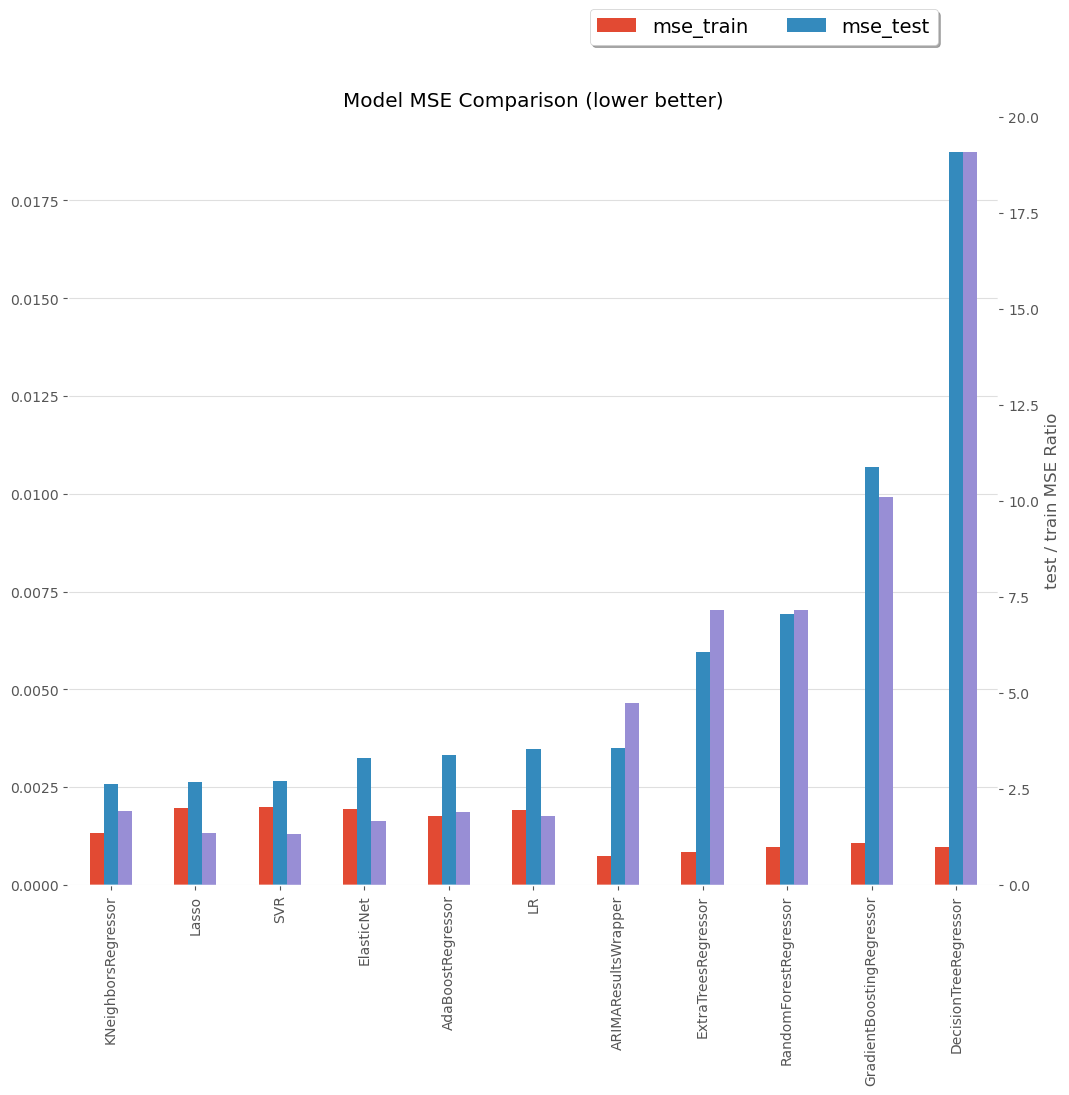

In [40]:
ax =\
(
    metrics.plot(
        secondary_y = 'mse_ratio',
        kind='bar',
        title='Model MSE Comparison (lower better)',
        ylabel='test / train MSE Ratio',
        figsize=(12, 10)
    )
)

ax.xaxis.grid(False)

(
    ax
    .legend(loc = "upper left",
            bbox_to_anchor = (0.55, 1.15),
            ncol = 4,
            shadow = True
           )
)

### <font color = red> Answer 1 is presented in the cell below: </font>

## <font color = blue> 👉 Questions 2 to 5 ask you to build, execute, and backtest a mean-reversion strategy, using `Relative Strength Index` (`RSI`). </font>

#### The Relative Strength Index (RSI) is an indicator that uses the closing prices of an asset to identify oversold and overbought conditions. 

> Most commonly, RSI is calculated using a 14-day period, and measured on a scale from zero to 100. (It is an oscillator.)

> Traders usually buy an asset when it is oversold (when its RSI is below 30) and sell when it is overbought (when its RSI is above 70). 

> More extreme overbought and oversold levels, such as 80 and 20, are used less frequently, and imply stronger momentum.

#### You are asked to build a trading strategy with the following set of rules.

### <font color = green> NOTE: Apple (`AAPL`) as our security of interest. The `investment horizon` will be three years between 2015 and 2017; your `capital` is USD 100,000; and there is a USD 5 flat `commission fee` per trade.

- You can go long and short.
<br>

- To calculate RSI, use 14 periods (trading days).
<br>

- Enter a long position if RSI crosses the lower threshold (standard value of 30), moving upwards. Exit the position when RSI becomes higher than the middle level (value of 50).
<br>

- Enter a short position if RSI crosses the upper threshold (standard value of 70), moving downwards. Exit the position when RSI becomes less than 50.
<br>

- Only one position can be open at a time.

### <font color = green> NOTE: The RSI is defined as follows:
    
### Calculating the RSI first requires the RS which requires an average value of n-many previous trading days. 
<br>
    
- As discussed, a value of 14 days is common for the RSI calculation. 
<br>
    
- The first RS value requires the price from all 14 of the first trading days. Often, this is a source of confusion with the RSI given successive values only require the most recent. 
   
    
    Step 1. For 14 periods, calculate the difference in price from the current period and the previous period
    
    Step 2. For each period, record each positive change in price as a gain and each negative change as a loss
    
    Step 3. On the 14th period, calculate the arithmetic mean of the gains and losses for the entire 14 day period (e.g. gains / 14 & losses / 14)
    
    Step 4. Use these values to calculate the RS
    
### <center> $ RS = \frac{AverageGain}{AverageLoss} $
    
    Step 5. Use the RS value to calculate the RSI
    
    Step 6. For each proceeding period, use only the previous RSI value to calculate the next average value 
    by multiplying by our lookback period – 1 (e.g., 13 for a lookback of 14).
    
    Step 7. Add the value obtained in Step 6 to the current day’s value (run this for both the gains and losses)
    
### <center> $ RSI = 100 - \frac{100}{1 + RS} $

### Visualize your buy and sell positions.

### Below are the lines of code that lead to an answer:

1. download aapl data
2. get rsi
3. get positions and trades
4. calculate strat returns
4. instantiate capital. iterrows and calculate cap
    - calculate cap after returns
    - if trade not 0 then charge 5

### <font color = red> Answer 2 is presented in the cell below: </font>

In [70]:
# TODO yf download
aapl=\
yf.download(
    ['AAPL'],
    start = '2014-11-01',
    end = '2018-01-01'
)['Close']

[*********************100%***********************]  1 of 1 completed


In [71]:
# get RSI

def get_rsi(df, period_list=[10, 20, 200]):
    """
    Calculate RSI (Relative Strength Index)
    
    Parameters:
    data: pandas df of closing price
    period: RSI period (default [10, 20, 200])
    
    Returns:
    pandas df with RSI values
    """
    # Calculate price changes
    delta = df[df.columns[0]].diff()
    
    for period in period_list:
        # Separate gains and losses
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        
        # get first average
        avg_gain = pd.Series(index=df.index, dtype='float64')
        avg_loss = pd.Series(index=df.index, dtype='float64')

        # get first average
        avg_gain.iloc[period] = gain.iloc[1:period+1].mean()    # start from period + 1 since diff() makes first NaN
        avg_loss.iloc[period] = loss.iloc[1:period+1].mean()

        # Calculate rolling averages
        for i in range(period + 1, len(df)): 
            avg_gain.iloc[i] = (avg_gain.iloc[i-1] * (period - 1) + gain.iloc[i]) / period
            avg_loss.iloc[i] = (avg_loss.iloc[i-1] * (period - 1) + loss.iloc[i]) / period

        # Calculate RS (Relative Strength)
        rs = avg_gain / avg_loss
        
        # Calculate RSI
        rsi = 100 - (100 / (1 + rs))

        df[f'rsi_{period}'] = rsi

    return df

In [72]:
aapl = get_rsi(aapl,[14])

In [73]:
aapl = aapl.dropna()

In [74]:
lower_threshold = 30
upper_threshold = 70
mid = 50

aapl['positions'] =\
(
    np.where(
        (aapl['rsi_14'].shift(1) < lower_threshold) & (aapl['rsi_14'] > lower_threshold),1,
            np.where(
                (aapl['rsi_14'].shift(1) < mid) & (aapl['rsi_14'] > mid), 0,
                    np.where(
                        (aapl['rsi_14'].shift(1) > mid) & (aapl['rsi_14'] < mid), 0,
                            np.where(
                                (aapl['rsi_14'].shift(1) > upper_threshold) & (aapl['rsi_14'] < upper_threshold), -1, np.nan
                            )
                    )
            )
    )
)
aapl['positions'] = aapl['positions'].ffill().fillna(0)

In [75]:
aapl = aapl.loc['2015-01-01':]

In [78]:
aapl['trade'] = \
(
    aapl['positions'].diff().fillna(0)
)
if aapl.at[aapl.index[0], 'positions'] != 0:
    aapl.at[aapl.index[0], 'trade'] = aapl.at[aapl.index[0], 'positions']
aapl['passive_returns'] = \
(
    np.log(
        aapl[aapl.columns[0]] / 
            aapl[aapl.columns[0]].shift(1)
    )
).fillna(0)
aapl['strategy_returns'] = \
(
    aapl['passive_returns'] * aapl['positions'].shift(1).fillna(0)
)
aapl['cum_passive_returns'] = \
(
    aapl['passive_returns'].cumsum().apply(np.exp).fillna(1)
)
aapl['cum_strategy_returns'] = \
(
    aapl['strategy_returns'].cumsum().apply(np.exp).fillna(1)
)

In [79]:
initial_cap = 100_000
cap = initial_cap
cum_strategy_returns = pd.Series(index=aapl.index)

for idx, row in aapl.iterrows():
    cap *= np.exp(row['strategy_returns'])
    if row['trade'] !=0:
        cap -= 5
    cum_strategy_returns.loc[idx] = cap

print(f"Final capital ${cap:,.0f}")

Final capital $82,250


In [80]:
aapl['portfolio'] = cum_strategy_returns

In [81]:
aapl

Ticker,AAPL,rsi_14,positions,trade,passive_returns,strategy_returns,cum_passive_returns,cum_strategy_returns,portfolio
Date,,,,,,,,,
2015-01-02,24.261044,42.491919,0.0,0.0,0.000000,0.0,1.000000,1.000000,100000.000000
2015-01-05,23.577574,35.953931,0.0,0.0,-0.028576,-0.0,0.971829,1.000000,100000.000000
2015-01-06,23.579790,35.988326,0.0,0.0,0.000094,0.0,0.971920,1.000000,100000.000000
2015-01-07,23.910433,41.072619,0.0,0.0,0.013925,0.0,0.985548,1.000000,100000.000000
2015-01-08,24.829126,52.388317,0.0,0.0,0.037703,0.0,1.023415,1.000000,100000.000000
...,...,...,...,...,...,...,...,...,...
2017-12-22,41.025646,60.560956,0.0,0.0,0.000000,0.0,1.691009,0.823615,82250.080679
2017-12-26,39.984833,46.701650,0.0,0.0,-0.025697,-0.0,1.648109,0.823615,82250.080679
2017-12-27,39.991867,46.790278,0.0,0.0,0.000176,0.0,1.648398,0.823615,82250.080679


In [82]:
# TODO get_plot lets-plot; basic 
from lets_plot import *
LetsPlot.setup_html()

aapl_melt = aapl.reset_index()
# aapl_melt = aapl_melt.rename(columns={'index':'Date'}). # optional depending if index is called 'Date'

p =\
(
    ggplot(aapl_melt, aes(x='Date')) +
    geom_line(aes(y='rsi_14'), color='grey', size=0.7) +
    # geom_line(aes(y='sma_50'), color='orange', size=0.7,linetype=2) +   # amend sma as required
    # geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
    geom_point(aes(y='rsi_14'), data=aapl_melt[aapl_melt['trade']>0.0], color='red', size=3) +       # amend trade as required
    geom_point(aes(y='rsi_14'), data=aapl_melt[aapl_melt['trade']<-0.0], color='blue', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)


p

### <font color = blue> 👉 Question 3</font>. How much in cumulative returns could you have had as a result of the RSI strategy?

### Below are the lines of code that lead to an answer:

In [83]:
def compute_CAGR(cumulative_returns):
    """
    get_cagr Compute Compound Annual Growth Rate (CAGR) from a series of cumulative returns.
        - The function drops missing values and uses the first and last available
      observations to compute CAGR as:
          (last_value / first_value) ** (365.0 / n_days) - 1
      where n_days is the integer number of days between the first and last index.
        - Uses 365-day convention for annualization. For trading-day conventions
        adjust the exponent accordingly.
        - If the series contains a single observation or zero-day span, the result
        may be ill-defined (division by zero or power of inf). Consider checking
        the index span before calling.
    Parameters:
        cumulative_returns : pandas.Series. Time-indexed series of cumulative returns (e.g. cumulative growth factors)
    Returns:
        float
    """

    cumulative_returns = cumulative_returns.dropna()
    n_of_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]
                ).days
    cagr =\
    (
        (        
        cumulative_returns.iloc[-1] 
        /
        cumulative_returns.iloc[0]
        ) ** (365.25 / n_of_days)
        - 1
    )
    return cagr

### <font color = red> Answer 3 </font>

    The answer is ____________ % .

In [84]:
f"The answer is {compute_CAGR(cum_strategy_returns):.2%}"

'The answer is -6.33%'

### <font color = blue> 👉 Question 4</font>. Now please find the `five` worst drawdown periods over the investment horizon and provide their net drawdown in % and duration, respectively.

### <font color = green> The question asks you to find the five worst drawdown periods, beyond identifying max drawdown (MDD).

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 4 </font>

    The Worst drawdown period     : Net drawdown ____________ % | Duration ____________ Days
    
    The 2nd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
     
    The 3rd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
         
    The 4th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
    
    The 5th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days

In [88]:
"""
 TODO get_drawdown_top max drawdown and duration table
"""

# daily_drawdown = cum_strategy_returns / cum_strategy_returns.cummax() - 1
aapl['daily_drawdown'] = aapl['cum_strategy_returns'] / aapl['cum_strategy_returns'].cummax() - 1
# take date column out and cumsum for periods
dd_reset = aapl.reset_index()
dd_reset['period'] = (dd_reset['daily_drawdown'] == 0).cumsum()
# find nodes with 0 value i.e. highpoints
dd_nonzero = dd_reset[dd_reset['daily_drawdown'] != 0]
# aggregate by period
period_stats = dd_nonzero.groupby('period').agg(
    start_date = ('Date', 'min'),
    end_date = ('Date', 'max'),
    avg_dd = ('daily_drawdown', 'mean'),
    max_dd = ('daily_drawdown', 'min'),
    duration=('daily_drawdown', 'count')
).sort_values(by='avg_dd',ascending=True)


## printing drawdowns
for i, row in enumerate(period_stats.itertuples(), start=1):
    ordinal = f"{i}{'tsnrhtdd'[i%5*(i%100^15>4>i%10)::4]}"
    print(f"The {ordinal} worst drawdown period : Net drawdown {row.max_dd:.2f}% | Duration {row.duration} Days\n")



The 1st worst drawdown period : Net drawdown -0.28% | Duration 603 Days

The 2nd worst drawdown period : Net drawdown -0.01% | Duration 1 Days

The 3rd worst drawdown period : Net drawdown -0.01% | Duration 3 Days

The 4th worst drawdown period : Net drawdown -0.01% | Duration 2 Days

The 5th worst drawdown period : Net drawdown -0.00% | Duration 1 Days



### <font color = blue> 👉 Question 5</font>. Within the investment horizon, please calculate annual returns for each of the three years and then find the year that performs better than average vs. less than average annual returns.

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 5 </font>

    Below average year(s) : ____________ 
    
    Above average year(s) : ____________ 
     

In [89]:
# Above and below average years
splits = [
            '2015-01-01',
            '2016-01-01',
            '2017-01-01',
            '2018-01-01',
]

dct = {}
ar_dct = {}

for idx, year in enumerate([2015, 2016, 2017]):
    dct[year] = aapl.loc[splits[idx]: splits[idx+1]]

for year, df in dct.items():
    cum_rets = df['strategy_returns'].cumsum().apply(np.exp).fillna(1)
    ar_dct[year] = cum_rets.iloc[-1] - 1

avg = (np.mean(list(ar_dct.values())))
above = [k for k, v in ar_dct.items() if v > avg]
below = [k for k, v in ar_dct.items() if v < avg]

f"    Below average year(s) : {below}. Above average year(s) : {above}" 

'    Below average year(s) : [2017]. Above average year(s) : [2015, 2016]'

###  <font color = blue> 👉 Question 6. </font> What's the annualized Sharpe ratio of the current investment strategy?

### Below are the lines of code that lead to an answer:

In [92]:
def compute_sharpe_ratio(daily_returns):
    """
    get_sharpe Calculate the annualized Sharpe ratio from a series of daily returns.
    Annualized Sharpe ratio computed as:
                sqrt(252) * mean(daily_returns) / std(daily_returns)
    - Assumes 252 trading days per year for annualization. Adjust the
      multiplier for a different convention.
    - Input should be returns (not prices). Convert prices to returns before
      calling this function.
    Parameters:
        daily_returns : array-like (pd.Series or np.ndarray)
    Returns:
        float
    Usage:
        compute_sharpe_ratio(df['strategy_returns'])
    """
    return np.sqrt(252) * daily_returns.mean() / daily_returns.std(ddof = 1)

# compute_sharpe_ratio(ibm['strategy_returns'])

### <font color = red> Answer 6 </font>
    
    Sharpe ratio: __________
    

In [95]:
res = compute_sharpe_ratio(aapl['strategy_returns'])

In [96]:
f" Sharpe ratio: {res:.2%}"

' Sharpe ratio: -44.12%'

> 💯 “Thank you for putting your efforts into the individual assessment questions” 😊